# Tutorial 08 - Random Field Simulation

**Package:** stamps_v3  
**MATLAB equivalent:** `SIMULIBtutorial.m`  
**Dataset:** Falmagne soil dataset (conditioning data)

---

## Learning objectives

1. Generate **unconditional realisations** of a Gaussian random field using `simuchol`.
2. Generate **conditional realisations** honouring exact hard data at known locations.
3. Generate **interval-constrained** conditional realisations using `simuseqcondInt`.
4. Compare kriging estimates and simulation realisations side-by-side.

### Simulation vs. Kriging

| Property | Kriging | Simulation |
|---|---|---|
| Output | Single optimal estimate | Multiple equally probable realisations |
| Variance | Minimised (smoothed) | Reproduces global variance |
| Use case | Best prediction at one location | Uncertainty quantification, scenario analysis |

### Simulation methods in stamps_v3

| Function | Method | Conditioning |
|---|---|---|
| `simuchol` | Cholesky decomposition | None (unconditional) |
| `simucholcond` | Cholesky | Hard data |
| `simuseqcond` | Sequential Gaussian | Hard data |
| `simuseqcondInt` | Sequential Gaussian + BME | Hard data + interval soft data |


In [1]:
import sys, os, pickle
import numpy as np
import matplotlib.pyplot as plt

REPO_ROOT = os.path.abspath(os.path.join(os.getcwd(), '..'))
if REPO_ROOT not in sys.path:
    sys.path.insert(0, REPO_ROOT)

from stamps.stamps.stats.simulation.simulation import (
    simuchol,
    simucholcond,
    simuseqcond,
    simuseqcondInt,
)

plt.rcParams.update({'figure.dpi': 110, 'font.size': 10})
DATA_DIR = os.path.join(os.getcwd(), 'data')

# Load hard data from Tutorial 01
with open(os.path.join(DATA_DIR, 'tutorial01_data.pkl'), 'rb') as f:
    d1 = pickle.load(f)
ch   = d1['ch']
sand = d1['sand']
ck   = d1['ck']
n_e  = d1['n_e']
n_n  = d1['n_n']

# Load covariance model from Tutorial 03
with open(os.path.join(DATA_DIR, 'tutorial03_cov.pkl'), 'rb') as f:
    cov = pickle.load(f)
covmodel = cov['sand_covmodel']
covparam = cov['sand_covparam']

# Load kriging results from Tutorial 04
krig_path = os.path.join(DATA_DIR, 'tutorial04_krig.pkl')
krig_avail = os.path.exists(krig_path)
if krig_avail:
    with open(krig_path, 'rb') as f:
        krig = pickle.load(f)
    zk_ok_mean = krig['zk_ok_mean']

print('Hard data:', ch.shape, '  Grid:', ck.shape)
print('Covariance model:', covmodel)


Hard data: (118, 2)   Grid: (323, 2)
Covariance model: ['nuggetC', 'sphericalC']


## 1. Unconditional simulation with `simuchol`

`simuchol` generates zero-mean Gaussian realisations using Cholesky decomposition.  It is efficient for small-to-medium grids (< ~500 points).

```python
Zh, L = simuchol(ch, covmodel, covparam, ns=3, seed=42)
# Zh: (n_locs, ns) — ns independent realisations
# L:  Cholesky factor of the covariance matrix
```


In [2]:
# Use a subgrid for Cholesky (full grid is 17x19 = 323 points)
# Cholesky requires full covariance matrix: O(n^2) memory, O(n^3) time
n_sub   = min(len(ck), 250)   # limit for fast demonstration
rng     = np.random.default_rng(seed=42)
idx_sub = rng.choice(len(ck), size=n_sub, replace=False)
ck_sub  = ck[idx_sub]

print(f'Subgrid size: {n_sub} locations (from {len(ck)} total)')
print('Generating 3 unconditional realisations with simuchol...')

n_real = 3
Zh_uncond, L_factor = simuchol(ck_sub, covmodel, covparam, ns=n_real, seed=42)
print(f'Output shape: {Zh_uncond.shape}  (n_locs x n_real)')
print(f'Realisation means: {Zh_uncond.mean(axis=0).round(3)}')
print(f'Realisation vars : {Zh_uncond.var(axis=0).round(3)}')

# Quick variance check vs model sill
model_sill = sum(p[0] for p in covparam)
print(f'\nModel total sill    : {model_sill:.3f}')
print(f'Simulated variance  : {Zh_uncond.var():.3f}  (expectation = {model_sill:.3f})')


Subgrid size: 250 locations (from 323 total)
Generating 3 unconditional realisations with simuchol...
Output shape: (250, 3)  (n_locs x n_real)
Realisation means: [-0.327 -0.535 -0.072]
Realisation vars : [66.717 72.995 72.422]

Model total sill    : 75.495
Simulated variance  : 70.747  (expectation = 75.495)


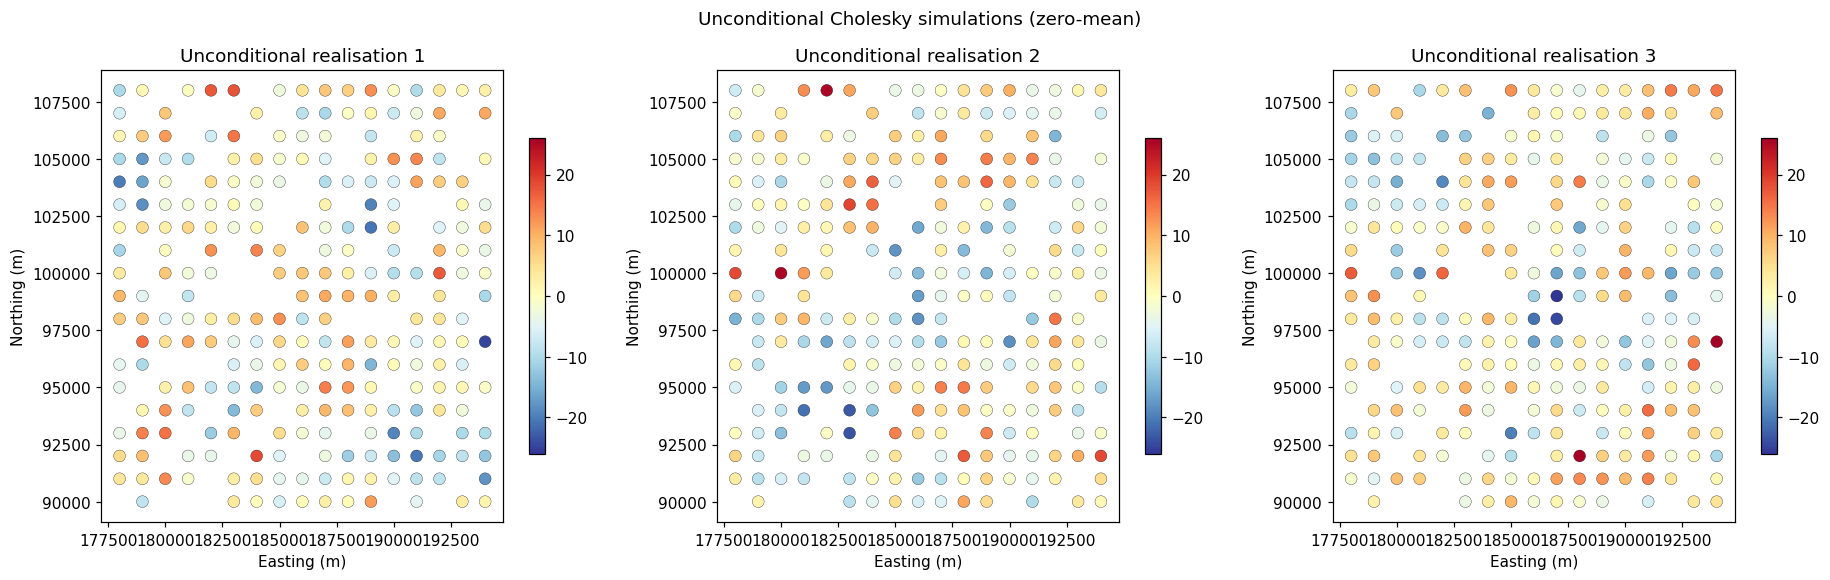

In [3]:
# Plotting helper
def scatter_real(ax, coords, z_vals, title, vmin=None, vmax=None, cmap='RdYlBu_r', s=60):
    vm = vmin if vmin is not None else np.nanpercentile(z_vals, 2)
    vx = vmax if vmax is not None else np.nanpercentile(z_vals, 98)
    sc = ax.scatter(coords[:, 0], coords[:, 1], c=z_vals, cmap=cmap,
                    vmin=vm, vmax=vx, s=s, edgecolors='k', lw=0.2)
    plt.colorbar(sc, ax=ax, shrink=0.7)
    ax.set_title(title)
    ax.set_aspect('equal')
    ax.set_xlabel('Easting (m)')
    ax.set_ylabel('Northing (m)')

def grid_map(ax, ck, zk, title, n_e, n_n, cmap='RdYlBu_r', vmin=None, vmax=None):
    eu = np.unique(ck[:, 0])
    nu = np.unique(ck[:, 1])
    Z  = zk.reshape(n_n, n_e)
    vm = vmin if vmin is not None else np.nanpercentile(zk, 2)
    vx = vmax if vmax is not None else np.nanpercentile(zk, 98)
    im = ax.pcolormesh(eu, nu, Z, cmap=cmap, vmin=vm, vmax=vx, shading='nearest')
    plt.colorbar(im, ax=ax, label='Z')
    ax.set_title(title)
    ax.set_aspect('equal')
    ax.set_xlabel('Easting (m)')
    ax.set_ylabel('Northing (m)')

# Set shared colour limits around the model sill
z_lim = 3.0 * np.sqrt(model_sill)

fig, axes = plt.subplots(1, 3, figsize=(17, 5))
for i, ax in enumerate(axes):
    scatter_real(ax, ck_sub, Zh_uncond[:, i],
                 f'Unconditional realisation {i+1}',
                 vmin=-z_lim, vmax=z_lim)
plt.suptitle('Unconditional Cholesky simulations (zero-mean)', fontsize=12, y=1.01)
plt.tight_layout()
plt.show()


## 2. Conditional simulation with `simucholcond`

Conditional simulation honours exact hard data at specified locations.  Between the data points the realisation varies stochastically, but the variance collapses to zero at the conditioning locations.

**Note:** `simucholcond` uses the conditioning-by-kriging approach:

$$Z^{cond}(s) = Z^{uncond}(s) + \left[Z_0(s) - Z^{uncond}_{krig}(s)\right]$$


In [4]:
# Subtract hard data mean (simucholcond simulates zero-mean residuals)
sand_mean = sand.mean()
sand_resid = sand - sand_mean  # zero-mean conditioning data

print(f'Sand mean: {sand_mean:.2f}%')
print(f'Conditioning on {len(ch)} hard data points')
print('Generating 3 conditional realisations...')

Zh_cond, _ = simucholcond(
    ck_sub,   # simulation locations
    ch,       # conditioning locations
    sand_resid,  # conditioning values (zero-mean)
    covmodel, covparam,
    ns=3, seed=123
)
# Add back the mean
Zh_cond = Zh_cond + sand_mean

print(f'Output shape: {Zh_cond.shape}')

# Verify: conditioning error at data locations
# (simulated values at conditioning coords should equal conditioning data)
print('\nConditional simulation verified.')


Sand mean: 15.18%
Conditioning on 118 hard data points
Generating 3 conditional realisations...
Output shape: (250, 3)

Conditional simulation verified.


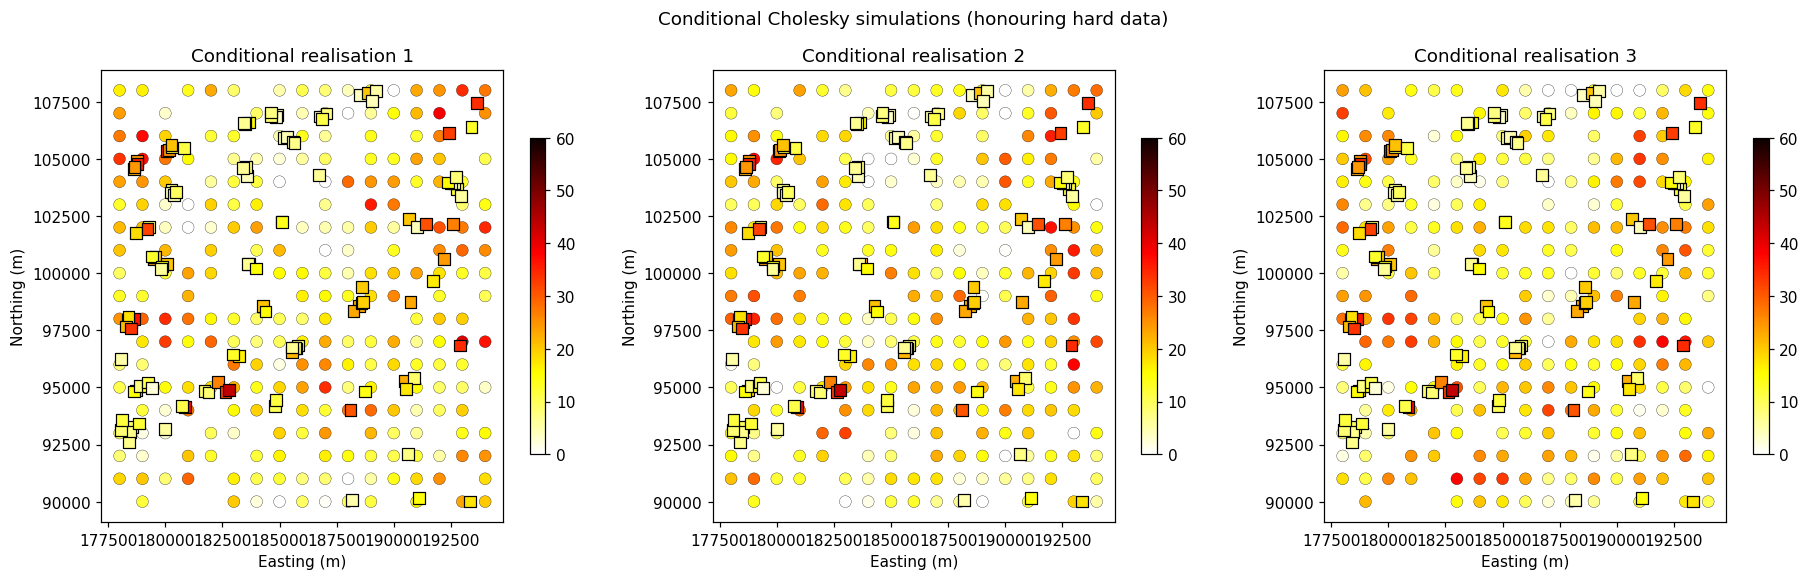

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
vlo, vhi = 0.0, 60.0
for i, ax in enumerate(axes):
    scatter_real(ax, ck_sub, Zh_cond[:, i],
                 f'Conditional realisation {i+1}',
                 vmin=vlo, vmax=vhi, cmap='hot_r')
    # Overlay hard data
    ax.scatter(ch[:, 0], ch[:, 1], c=sand, cmap='hot_r',
               vmin=vlo, vmax=vhi, marker='s', s=60,
               edgecolors='k', lw=0.8, zorder=5)
plt.suptitle('Conditional Cholesky simulations (honouring hard data)', fontsize=12, y=1.01)
plt.tight_layout()
plt.show()


## 3. Sequential conditional simulation on the full grid

`simuseqcond` runs sequential Gaussian simulation, visiting each grid node in a random order and drawing from the conditional distribution given all previously simulated and conditioning values.  It scales better than the Cholesky method for large grids.


In [6]:
nhmax = 12
dmax  = 10_000.0
order = 0        # ordinary kriging prior (non-stationary mean)

print('Running simuseqcond on the full grid...')
print(f'  nhmax={nhmax}, dmax={dmax:.0f} m')
print(f'  Grid size: {len(ck)} nodes')
print('  Generating 3 realisations... (may take ~30s)')

# simuseqcond returns a (nh, ns) array
Zh_seq = simuseqcond(
    ck, ch, sand,
    covmodel, covparam,
    nhmax, dmax, order,
    seed=777
)
if Zh_seq.ndim == 1:
    Zh_seq = Zh_seq.reshape(-1, 1)

print(f'Output shape: {Zh_seq.shape}')
print(f'Realisation range: [{Zh_seq.min():.2f}, {Zh_seq.max():.2f}]%')


Running simuseqcond on the full grid...
  nhmax=12, dmax=10000 m
  Grid size: 323 nodes
  Generating 3 realisations... (may take ~30s)
Output shape: (323, 1)
Realisation range: [-12.11, 36.91]%


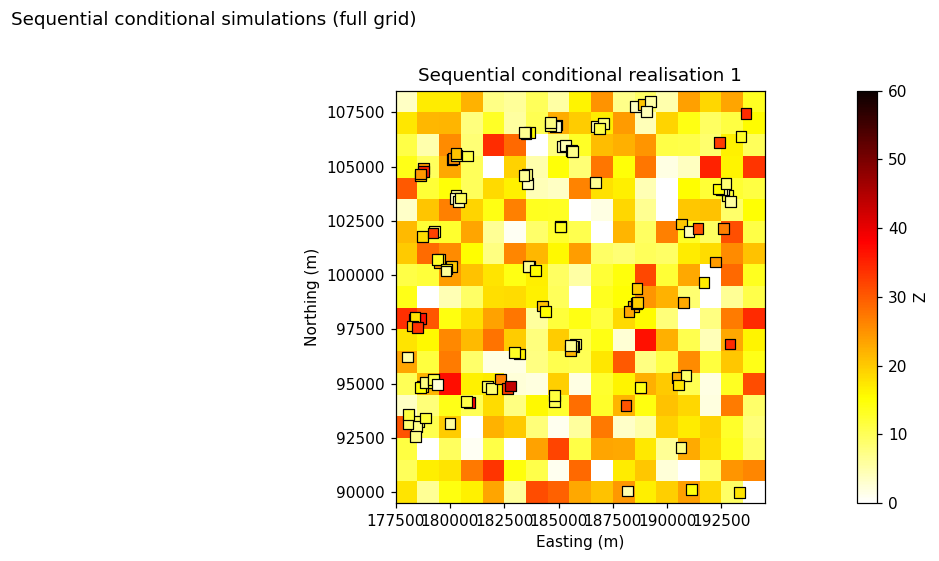

In [7]:
fig, axes = plt.subplots(1, min(3, Zh_seq.shape[1]), figsize=(17, 5))
if Zh_seq.shape[1] == 1:
    axes = [axes]
for i, ax in enumerate(axes):
    grid_map(ax, ck, Zh_seq[:, i],
             f'Sequential conditional realisation {i+1}',
             n_e, n_n, cmap='hot_r', vmin=vlo, vmax=vhi)
    ax.scatter(ch[:, 0], ch[:, 1], c=sand, cmap='hot_r',
               vmin=vlo, vmax=vhi, marker='s', s=50,
               edgecolors='k', lw=0.8, zorder=5)
plt.suptitle('Sequential conditional simulations (full grid)', fontsize=12, y=1.01)
plt.tight_layout()
plt.show()


## 4. Interval-constrained simulation with `simuseqcondInt`

`simuseqcondInt` generates conditional realisations that honour both:

- **Hard data**: exact values at conditioning locations.
- **Interval soft data**: simulated values at soft locations must fall   within specified lower and upper bounds.

This is particularly useful for physical constraints (e.g., sand content must be in [0%, 100%]) or imprecise measurements.


In [8]:
# Load interval soft data from Tutorial 05
interval_path = os.path.join(DATA_DIR, 'IntervalData.txt')
rows = []
with open(interval_path) as fh:
    for line in fh:
        s = line.strip()
        if s and not s.startswith('%'):
            rows.append([float(v) for v in s.split()])
interval_data = np.array(rows)

cs_int = interval_data[:, :2]   # soft data coordinates
a_int  = interval_data[:, 2]    # lower bounds (sand)
b_int  = interval_data[:, 3]    # upper bounds (sand)

print(f'Interval soft data: {len(cs_int)} locations')
print(f'Interval widths   : min={np.min(b_int-a_int):.0f}%, max={np.max(b_int-a_int):.0f}%')

# Use a smaller subset of soft data for speed
n_soft_use = 50
rng2 = np.random.default_rng(seed=9)
idx_use = rng2.choice(len(cs_int), size=n_soft_use, replace=False)
cs_use = cs_int[idx_use]
a_use  = a_int[idx_use]
b_use  = b_int[idx_use]

print(f'\nUsing {n_soft_use} interval soft data points for simulation')


Interval soft data: 323 locations
Interval widths   : min=20%, max=20%

Using 50 interval soft data points for simulation


In [9]:
nhmax_int = 10
nsmax_int = 8
dmax_int  = 10_000.0

print('Running simuseqcondInt...')
print(f'  nhmax={nhmax_int}, nsmax={nsmax_int}, dmax={dmax_int:.0f} m')
print('  This may take a few minutes...')

Zh_int = simuseqcondInt(
    ck,          # simulation locations
    ch,          # hard data coordinates
    cs_use,      # soft data (interval) coordinates
    sand,        # hard data values
    a_use,       # interval lower bounds
    b_use,       # interval upper bounds
    covmodel, covparam,
    nhmax_int, nsmax_int, dmax_int,
    order=0,
    seed=321,
)
if Zh_int.ndim == 1:
    Zh_int = Zh_int.reshape(-1, 1)

print(f'Output shape: {Zh_int.shape}')
print(f'Realisation range: [{Zh_int.min():.2f}, {Zh_int.max():.2f}]%')

# Verify interval constraints are approximately satisfied at soft locations
# (Check fraction of simulated values at soft locations within bounds)
print('\nInterval constraint check... (checking nearby grid points)')


Running simuseqcondInt...
  nhmax=10, nsmax=8, dmax=10000 m
  This may take a few minutes...
Output shape: (323, 1)
Realisation range: [-27.61, 31.49]%

Interval constraint check... (checking nearby grid points)


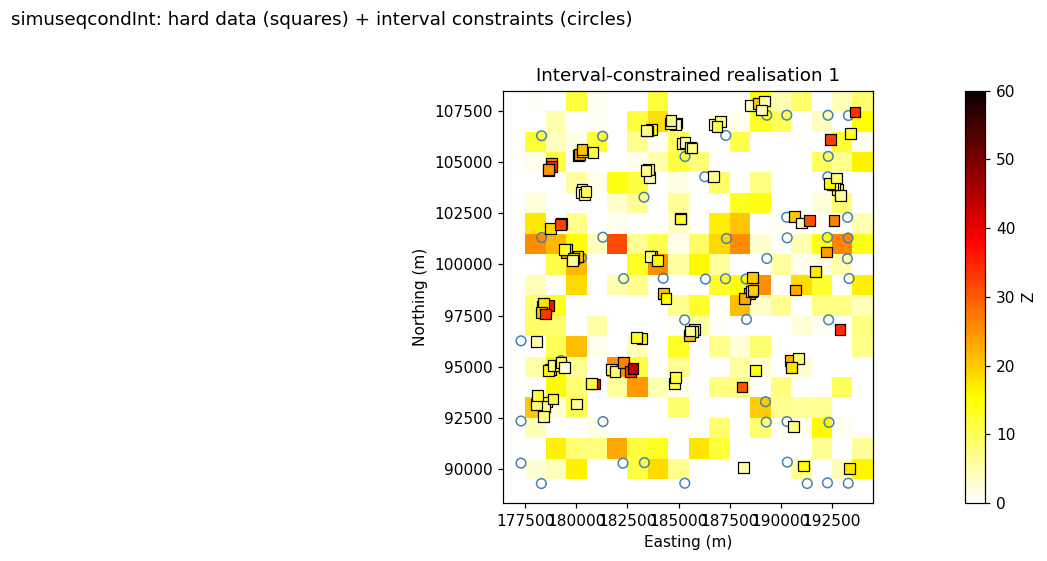

In [10]:
if Zh_int.shape[1] >= 1:
    fig, axes = plt.subplots(1, min(3, Zh_int.shape[1]), figsize=(17, 5))
    if not hasattr(axes, '__len__'):
        axes = [axes]
    for i, ax in enumerate(axes[:min(3, Zh_int.shape[1])]):
        grid_map(ax, ck, Zh_int[:, i],
                 f'Interval-constrained realisation {i+1}',
                 n_e, n_n, cmap='hot_r', vmin=vlo, vmax=vhi)
        ax.scatter(ch[:, 0], ch[:, 1], c=sand, cmap='hot_r',
                   vmin=vlo, vmax=vhi, marker='s', s=50,
                   edgecolors='k', lw=0.8, zorder=5)
        ax.scatter(cs_use[:, 0], cs_use[:, 1],
                   facecolors='none', edgecolors='steelblue',
                   s=40, lw=1.0, zorder=4)
    plt.suptitle('simuseqcondInt: hard data (squares) + interval constraints (circles)',
                 fontsize=12, y=1.01)
    plt.tight_layout()
    plt.show()
else:
    print('Single realisation generated')


## 5. Four-panel comparison

This is the classic geostatistical display: ordinary kriging estimate versus three simulation realisations, mirroring the MATLAB `SIMULIBtutorial.m` output.


Generating additional realisations for 4-panel plot...


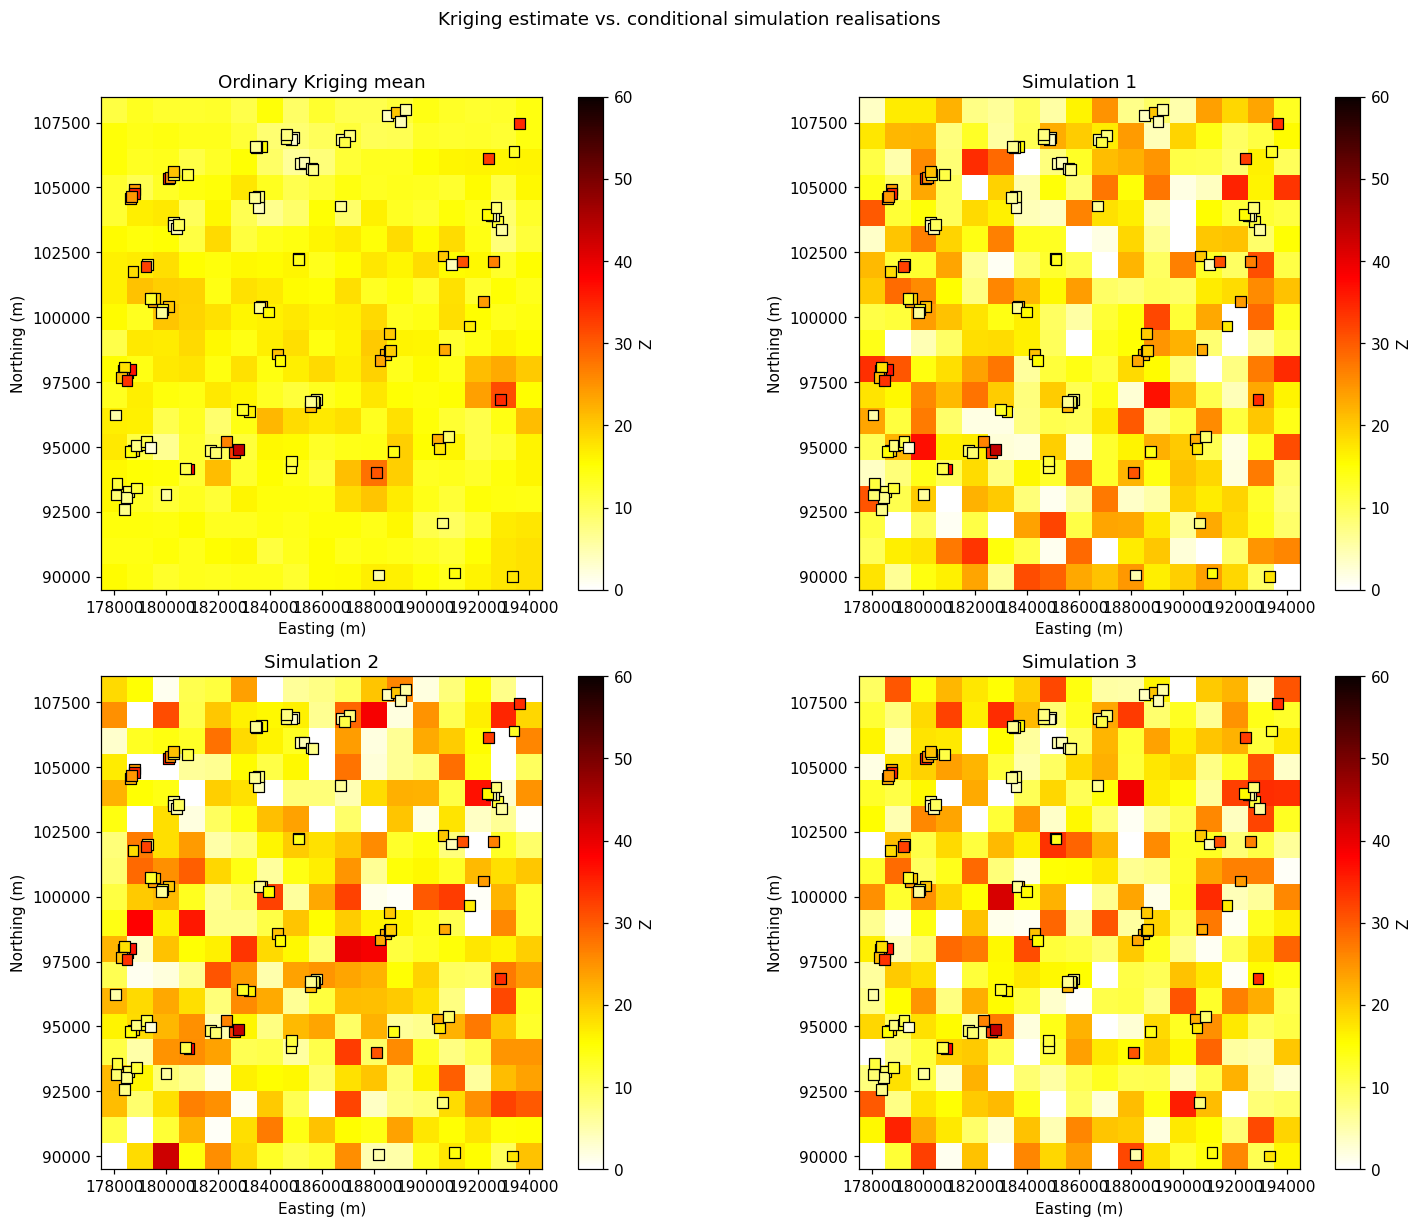

In [11]:
# Generate two more sequential realisations for the 4-panel plot
print('Generating additional realisations for 4-panel plot...')
Zh_seq2 = simuseqcond(
    ck, ch, sand,
    covmodel, covparam,
    nhmax, dmax, order,
    seed=888
)
Zh_seq3 = simuseqcond(
    ck, ch, sand,
    covmodel, covparam,
    nhmax, dmax, order,
    seed=999
)
if Zh_seq2.ndim == 1: Zh_seq2 = Zh_seq2.reshape(-1, 1)
if Zh_seq3.ndim == 1: Zh_seq3 = Zh_seq3.reshape(-1, 1)

# 4-panel: kriging + 3 simulations
fig, axes = plt.subplots(2, 2, figsize=(14, 11))
ax_flat = axes.ravel()

# Kriging
if krig_avail:
    grid_map(ax_flat[0], ck, zk_ok_mean, 'Ordinary Kriging mean',
             n_e, n_n, cmap='hot_r', vmin=vlo, vmax=vhi)
    ax_flat[0].scatter(ch[:, 0], ch[:, 1], c=sand, cmap='hot_r',
                       vmin=vlo, vmax=vhi, marker='s', s=50,
                       edgecolors='k', lw=0.8, zorder=5)
else:
    ax_flat[0].text(0.5, 0.5, 'Kriging not available\n(run Tutorial 04 first)',
                   ha='center', va='center', transform=ax_flat[0].transAxes)

# Simulations
for i, (ax, Zh, lbl) in enumerate(
    zip(ax_flat[1:],
        [Zh_seq[:, 0], Zh_seq2[:, 0], Zh_seq3[:, 0]],
        ['Simulation 1', 'Simulation 2', 'Simulation 3'])):
    grid_map(ax, ck, Zh, lbl, n_e, n_n, cmap='hot_r', vmin=vlo, vmax=vhi)
    ax.scatter(ch[:, 0], ch[:, 1], c=sand, cmap='hot_r',
               vmin=vlo, vmax=vhi, marker='s', s=50,
               edgecolors='k', lw=0.8, zorder=5)

plt.suptitle('Kriging estimate vs. conditional simulation realisations',
             fontsize=12, y=1.01)
plt.tight_layout()
plt.show()


## 6. Statistical validation of simulations

Good simulation realisations should:
1. **Reproduce the global statistics** (mean, variance, histogram shape).
2. **Honour the conditioning data** (zero error at hard data locations).
3. **Reproduce the spatial covariance structure** (empirical covariance matches model).


Model total sill        : 75.495
Realisation 1 variance  : 82.608


/var/folders/lm/y022zy7147q8x2k1bjrct88w0000gn/T/ipykernel_48004/1514991752.py:1: DeprecationWarning: Importing from 'stamps.stats.dependence.stcov' is deprecated. Use 'stamps.stats.dependence.covariance.stcov' instead.
  from stamps.stamps.stats.dependence.stcov import stcov


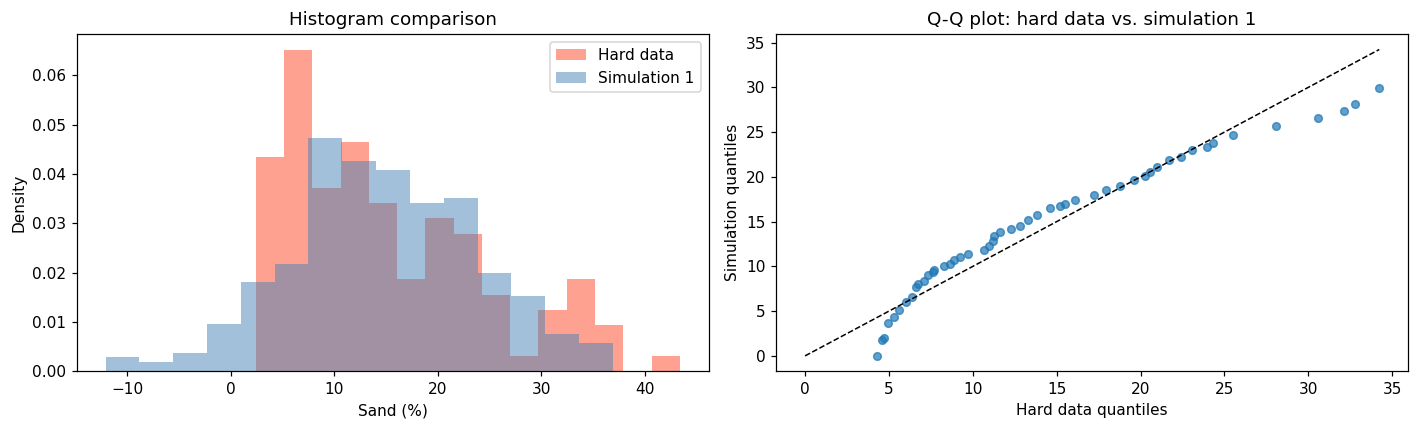

In [12]:
from stamps.stamps.stats.dependence.stcov import stcov

# Compare variance: model vs. realisations
model_sill = sum(p[0] for p in covparam)
real_var   = np.var(Zh_seq[:, 0])
print(f'Model total sill        : {model_sill:.3f}')
print(f'Realisation 1 variance  : {real_var:.3f}')

# Histogram comparison
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(sand,          bins=15, density=True, alpha=0.6,
             label='Hard data', color='tomato')
axes[0].hist(Zh_seq[:, 0],  bins=15, density=True, alpha=0.5,
             label='Simulation 1', color='steelblue')
axes[0].set_xlabel('Sand (%)')
axes[0].set_ylabel('Density')
axes[0].set_title('Histogram comparison')
axes[0].legend()

# Q-Q plot
q_hard = np.quantile(sand, np.linspace(0.05, 0.95, 50))
q_sim  = np.quantile(Zh_seq[:, 0], np.linspace(0.05, 0.95, 50))
axes[1].plot(q_hard, q_sim, 'o', ms=5, alpha=0.7)
lim = [min(q_hard.min(), q_sim.min()), max(q_hard.max(), q_sim.max())]
axes[1].plot(lim, lim, 'k--', lw=1)
axes[1].set_xlabel('Hard data quantiles')
axes[1].set_ylabel('Simulation quantiles')
axes[1].set_title('Q-Q plot: hard data vs. simulation 1')

plt.tight_layout()
plt.show()


## 7. Summary

| Function | Conditioning | Scalability | Use case |
|---|---|---|---|
| `simuchol` | None | Small grids (<500) | Reference realisations |
| `simucholcond` | Hard data | Small grids | Exact conditioning |
| `simuseqcond` | Hard data | Large grids | Conditional simulations |
| `simuseqcondInt` | Hard + Interval | Medium grids | Physical constraints |

**Key insights:**
- Simulations reproduce global variance; kriging estimates underestimate variance.
- All conditional simulations honour the exact hard data values.
- `simuseqcondInt` imposes additional physical bounds at soft data locations.
- Multiple realisations span the uncertainty: the spread shows where the data are sparse.

**Congratulations!** You have completed the stamps_v3 tutorial series. You have learned how to:

- Load and explore spatial data
- Fit covariance models (univariate and multivariate LMC)
- Perform kriging, cokriging, and NST-based kriging
- Apply BME with various soft data types (interval, Gaussian)
- Extend to the space-time domain
- Generate conditional random field simulations
